# EnhancedEmotionNet96 Inference Notebook

In [1]:
import os, time
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from torchvision import transforms
import mediapipe as mp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


## Model

In [2]:
class SqueezeExcitation(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        w = self.fc(x).view(b, c, 1, 1)
        return x * w

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.se = SqueezeExcitation(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class EnhancedEmotionNet96(nn.Module):
    def __init__(self, num_classes=8):  # Updated default parameter to 8
        super().__init__()
        
        self.prep = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        
        self.layer1 = ResidualBlock(64, 64, stride=1)   # (64, 96, 96)
        self.pool1 = nn.MaxPool2d(2)                    # (64, 48, 48)
        
        self.layer2 = ResidualBlock(64, 128, stride=1)  # (128, 48, 48)
        self.pool2 = nn.MaxPool2d(2)                    # (128, 24, 24)
        
        self.layer3 = ResidualBlock(128, 256, stride=1) # (256, 24, 24)
        self.pool3 = nn.MaxPool2d(2)                    # (256, 12, 12)
        
        self.layer4 = ResidualBlock(256, 512, stride=1) # (512, 12, 12)
        self.pool4 = nn.MaxPool2d(2)                    # (512, 6, 6)

        # Fixes structural alignment issue completely across dimension branches
        self.mid_bridge = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(6) # Rigidly enforces 6x6 target shape
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(23040, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.prep(x)
        x1 = self.pool1(self.layer1(x))
        x2 = self.pool2(self.layer2(x1))
        x3 = self.pool3(self.layer3(x2))  
        x4 = self.pool4(self.layer4(x3))  
        
        mid_features = self.mid_bridge(x3)
        fused = torch.cat([x4, mid_features], dim=1)
        return self.classifier(fused)


In [3]:
# Configuration
WEIGHTS_PATH = "90_10_model.pth"
IMAGE_PATH = "Aalia.jpg" 

CLASS_NAMES = [
    "anger",
    "contempt",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]


In [4]:
# Load model once
model = EnhancedEmotionNet96(num_classes=len(CLASS_NAMES)).to(device)
state = torch.load(WEIGHTS_PATH, map_location=device)
model.load_state_dict(state, strict=True)
model.eval()
print("Model loaded successfully.")


Model loaded successfully.


In [5]:
transform = transforms.Compose([
    transforms.Resize((96,96)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

mp_face = mp.solutions.face_detection.FaceDetection(
    model_selection=1,
    min_detection_confidence=0.5
)

def predict_image(image_path):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(image_path)

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h,w,_ = img_rgb.shape

    results = mp_face.process(img_rgb)

    if results.detections:
        box = results.detections[0].location_data.relative_bounding_box
        margin=0.2
        xmin=max(0,int((box.xmin-box.width*margin)*w))
        ymin=max(0,int((box.ymin-box.height*margin)*h))
        xmax=min(w,int((box.xmin+box.width*(1+margin))*w))
        ymax=min(h,int((box.ymin+box.height*(1+margin))*h))
        crop=img_rgb[ymin:ymax,xmin:xmax]
        cv2.rectangle(img_bgr,(xmin,ymin),(xmax,ymax),(0,255,0),2)
    else:
        crop=img_rgb

    tensor=transform(Image.fromarray(crop)).unsqueeze(0).to(device)

    start=time.time()
    with torch.no_grad():
        if device.type=="cuda":
            with torch.amp.autocast(device_type="cuda"):
                out=model(tensor)
        else:
            out=model(tensor)
    elapsed=(time.time()-start)*1000

    probs=torch.softmax(out,1)[0].cpu()
    top_p, top_i=torch.topk(probs,3)

    fig,ax=plt.subplots(1,3,figsize=(16,5))
    ax[0].imshow(cv2.cvtColor(img_bgr,cv2.COLOR_BGR2RGB))
    ax[0].set_title("Detected Face")
    ax[0].axis("off")

    ax[1].imshow(crop)
    ax[1].set_title(f"{CLASS_NAMES[top_i[0]]}\n{top_p[0]*100:.2f}%")
    ax[1].axis("off")

    ax[2].bar(CLASS_NAMES, probs.numpy())
    ax[2].tick_params(axis='x', rotation=45)
    ax[2].set_ylabel("Probability")

    plt.tight_layout()
    plt.show()

    print(f"Inference Time: {elapsed:.2f} ms")
    print("\nTop-3 Predictions")
    for p,i in zip(top_p,top_i):
        print(f"{CLASS_NAMES[i]:10s}: {p.item()*100:.2f}%")


libEGL warning: pci id for fd 117: 10de:28a0, driver (null)

pci id for fd 118: 10de:28a0, driver (null)
pci id for fd 119: 10de:28a0, driver (null)
libEGL warning: egl: failed to create dri2 screen
pci id for fd 118: 10de:28a0, driver (null)
pci id for fd 119: 10de:28a0, driver (null)
libEGL warning: egl: failed to create dri2 screen
I0000 00:00:1784014398.472763   28477 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1784014398.511406   28575 gl_context.cc:357] GL version: 3.2 (OpenGL ES 3.2 Mesa 26.0.3-1ubuntu1), renderer: llvmpipe (LLVM 21.1.8, 256 bits)


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1784014398.535273   28536 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
/home/masood/Projects/FER/.venv3.12/lib/python3.12/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


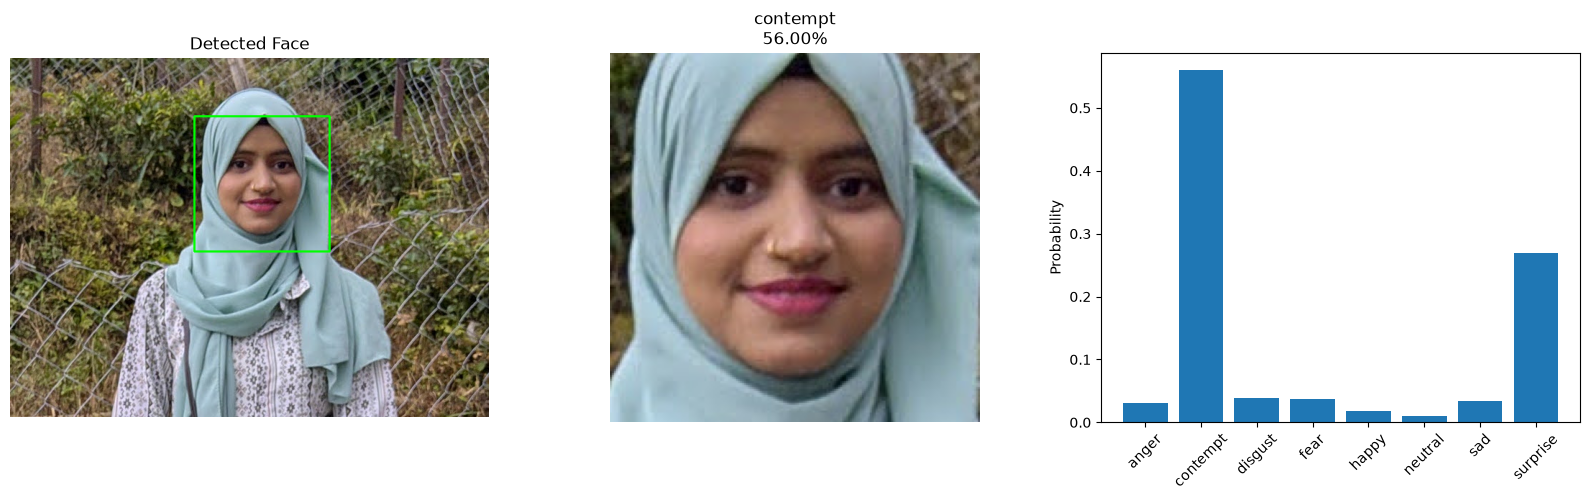

Inference Time: 473.48 ms

Top-3 Predictions
contempt  : 56.01%
surprise  : 26.86%
disgust   : 3.89%


In [6]:
predict_image(IMAGE_PATH)